In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.pylabtools import figsize

crop_df = pd.read_csv('data/FAOSTAT_Production.csv')
price_df = pd.read_csv('data/FAOSTAT_Producer_Prices.csv')

conn = sqlite3.connect('crop_data.db')

crop_df.to_sql('crop_production', conn, if_exists='replace', index=False)
price_df.to_sql('producer_price', conn, if_exists='replace', index=False)

214

I imported th necessary libraries. I defined two variables that contain the pandas dataframes fro each csv. I defined 'conn' to connect to a database. I converted the dataframes to sql tables.

In [2]:
query = "SELECT * FROM 'crop_production' LIMIT 5"
pd.read_sql_query(query, conn)

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,250,France,5312,Area harvested,115,Barley,2014,2014,ha,1764346.0,A,Official value,None
1,QCL,Crops and livestock products,250,France,5412,Yield,115,Barley,2014,2014,kg/ha,6647.5,A,Official value,None
2,QCL,Crops and livestock products,250,France,5510,Production,115,Barley,2014,2014,t,11728556.0,A,Official value,None
3,QCL,Crops and livestock products,250,France,5312,Area harvested,115,Barley,2015,2015,ha,1838689.0,A,Official value,None
4,QCL,Crops and livestock products,250,France,5412,Yield,115,Barley,2015,2015,kg/ha,7123.7,A,Official value,None


In [3]:
query = "SELECT * FROM 'producer_price' LIMIT 5"
pd.read_sql_query(query, conn)

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Months Code,Months,Unit,Value,Flag,Flag Description
0,PP,Producer Prices,250,France,5532,Producer Price (USD/tonne),115,Barley,2014,2014,7021,Annual value,USD,200.3,A,Official value
1,PP,Producer Prices,250,France,5532,Producer Price (USD/tonne),115,Barley,2015,2015,7021,Annual value,USD,166.2,A,Official value
2,PP,Producer Prices,250,France,5532,Producer Price (USD/tonne),115,Barley,2016,2016,7021,Annual value,USD,138.5,A,Official value
3,PP,Producer Prices,250,France,5532,Producer Price (USD/tonne),115,Barley,2017,2017,7021,Annual value,USD,149.7,A,Official value
4,PP,Producer Prices,250,France,5532,Producer Price (USD/tonne),115,Barley,2018,2018,7021,Annual value,USD,195.2,A,Official value


The tables have 3 shared keys (Area, Item, Year) that allow them to be joined.

In [4]:
query1 = """
SELECT Item AS 'Crop', Value AS 'Yield', Area AS 'Country'
FROM crop_production
WHERE Year = 2023
AND Element = 'Yield'
AND Area != 'United States of America'
ORDER BY Value DESC
"""

crop_yields = pd.read_sql_query(query1, conn)
crop_yields


,Crop,Yield,Country
0,Maize (corn),9762.5,France
1,Maize (corn),9646.0,Germany
2,Maize (corn),7806.0,Ukraine
3,Wheat,7431.8,Germany
4,Wheat,7201.6,France
5,Barley,6822.9,Germany
6,Barley,6688.8,France
7,Wheat,4642.2,Ukraine
8,Wheat,4152.4,Romania
9,Barley,4013.1,Romania


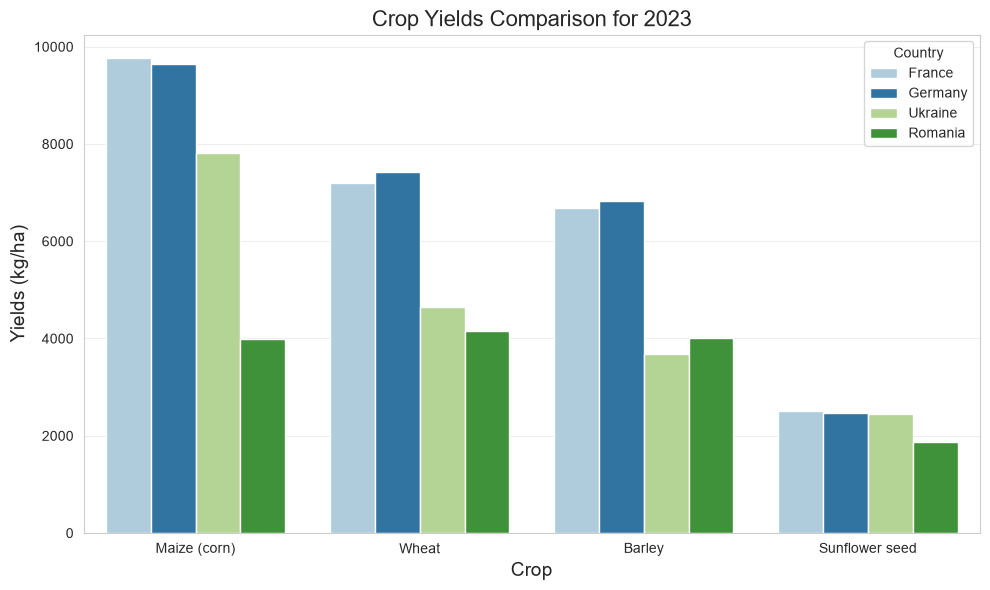

In [5]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(data=crop_yields, x='Crop', y='Yield', hue='Country', palette='Paired')
plt.title('Crop Yields Comparison for 2023', fontsize=16)
plt.xlabel('Crop', fontsize=14)
plt.ylabel('Yields (kg/ha)', fontsize=14)
plt.tight_layout()
plt.show()

For each crop, is Romania's yield (kg/ha) closer to Ukraine's or to France/Germany's?
For wheat and barley, Romania's yield was closer to Ukraine's. For maize, Romania sat well below even Ukraine's yield, which was closer to that of France of Germany. For Sunflower seeds, Romania fell jsut short of the other countries yields, which were virtually equal.

In [6]:
query = """
SELECT Item AS 'Crop', Area AS 'Country', AVG(Value) AS 'Yield_Average'
FROM crop_production
WHERE Element = 'Yield'
GROUP BY Country, Item
ORDER BY Country, Item;
"""
rel_yield_gap = pd.read_sql_query(query, conn)

rel_yield_gap_pivot = rel_yield_gap.pivot_table(values='Yield_Average', index='Country', columns='Crop')

rel_yield_gap_pivot

Crop,Barley,Maize (corn),Sunflower seed,Wheat
Country,,,,
France,6237.636364,8944.636364,2270.818182,6907.800000
Germany,6745.618182,9507.518182,2185.800000,7571.536364
Romania,3867.945455,4764.345455,2186.972727,4161.618182
Ukraine,3336.054545,6642.936364,2227.281818,4143.409091
United States of America,3943.054545,10985.663636,1859.772727,3215.036364


In [7]:
peers = ['France', 'Germany', 'Ukraine', 'United States of America']
crops = ['Barley', 'Maize (corn)', 'Sunflower seed', 'Wheat']

result_df = pd.DataFrame(index=peers, columns=crops)

for peer in peers:
    for crop in crops:
        peer_yield = rel_yield_gap_pivot.loc[peer, crop]
        ro_yield = rel_yield_gap_pivot.loc['Romania', crop]
        gap = ((peer_yield - ro_yield) / peer_yield) * 100
        result_df.loc[peer, crop] = round(gap, 2)

result_df = result_df.rename(index={'United States of America': 'USA'}).astype(float)
result_df

,Barley,Maize (corn),Sunflower seed,Wheat
France,37.99,46.74,3.69,39.75
Germany,42.66,49.89,-0.05,45.04
Ukraine,-15.94,28.28,1.81,-0.44
USA,1.90,56.63,-17.59,-29.44


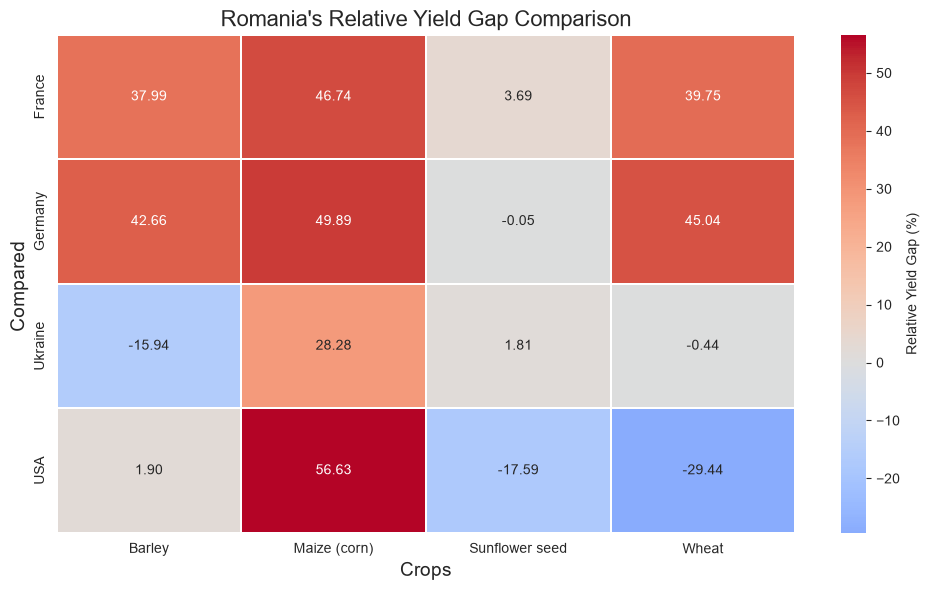

In [8]:
plt.figure(figsize=(10, 6))
sns.heatmap(data=result_df.astype(float),
            cmap='coolwarm',
            annot=True, fmt='.2f',
            center=0,
            linewidths=0.1, linecolor='white',
            cbar_kws={'label': 'Relative Yield Gap (%)'}
)
plt.title("Romania's Relative Yield Gap Comparison", fontsize=16)
plt.xlabel('Crops', fontsize=14)
plt.ylabel('Compared ', fontsize=14)
plt.tight_layout()
plt.show()

What is Romania's relative yield gap, in percentage terms, to each of the four peer countries, per crop?

Gap = `(peer_yield − Romania_yield) / peer_yield × 100`. Positive = Romania trails, Negative = Romania leads.

- **Barley**: Romania has close to 40% worse yield than France and Germany, 16% better yield than Ukraine and almost the same yield as the USA.
- **Maize**: Romania is significantly behind all peers, at around 50%, except Ukraine which still has almost 30% more.
- **Sunflower**: Most competitive crop for Romania, having about the same yields as all peers except the USA, which is outperformed at around 18% more yield.
- **Wheat**: Romania has a similar relative yield gaps with France and Germany at around 40-45%, matches Ukraine's yield and outperforms the USA again with almost 30% better yields.

**Pattern**:Romania consistently lags France and Germany across all crops, except for Sunflower (where it is competitive). Ukraine’s performance flips by crop: it is better in Maize, worse in Barley, and about the same in sunflower seeds and wheat. USA is the most extreme comparison: Romania has the largest deficit in Maize and largest lead in Sunflower and Wheat.

**Note**: Ukraine’s figures may reflect disruptions from the the war, including land loss and reduced harvested area post 2021.

In [9]:
query = """
SELECT Area AS 'Country', Item AS 'Crop', Value AS 'Yield', Year
FROM crop_production
WHERE Country IN ('Romania', 'Germany')
AND Element = 'Yield'
GROUP BY Country, Item, Year
ORDER BY Country, Item, Year
"""
ro_ger_comp = pd.read_sql_query(query, conn)

ro_ger_comp_pivot = ro_ger_comp.pivot_table(index=('Country', 'Crop'), columns='Year', values='Yield')

romania = ro_ger_comp_pivot.loc['Romania']
germany = ro_ger_comp_pivot.loc['Germany']

ro_ger_comp_pivot

Year                       2014    2015    2016     2017    2018    2019  \
Country Crop                                                               
Germany Barley           7347.5  7171.0  6685.7   6930.2  5766.3  6783.4   
        Maize (corn)    10683.8  8722.3  9651.2  10526.9  8139.0  8809.6   
        Sunflower seed   2300.0  1918.5  2137.7   2200.0  1820.5  2044.4   
        Wheat            8629.6  8087.7  7640.9   7644.3  6673.7  7396.4   
Romania Barley           3343.8  3470.8  3778.6   4190.3  4417.3  4188.0   
        Maize (corn)     4787.0  3471.6  4167.7   5961.0  7636.8  6499.9   
        Sunflower seed   2193.6  1769.6  1957.2   2915.2  3041.4  2782.5   
        Wheat            3598.4  3787.2  3948.4   4891.1  4793.5  4748.8   

Year                      2020     2021    2022    2023     2024  
Country Crop                                                      
Germany Barley          6459.1   6762.7  7081.4  6822.9   6391.6  
        Maize (corn)    9587.4  10360.8  8402.5  9646.0  10053.2  
        Sunflower seed  2056.7   2603.1  1883.2  2468.8   2610.9  
        Wheat           7819.5   7301.5  7577.3  7431.8   7084.2  
Romania Barley          2581.6   4408.3  4006.7  4013.1   4148.9  
        Maize (corn)    3974.2   5801.4  3297.7  3981.6   2828.9  
        Sunflower seed  1857.5   2529.9  1926.9  1870.0   1212.9  
        Wheat           2966.0   4796.9  4004.4  4152.4   4090.7

In [10]:
romania_pct_of_germany = ((romania / germany) * 100).round(1)
romania_pct_of_germany

Year,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Crop,,,,,,,,,,,
Barley,45.5,48.4,56.5,60.5,76.6,61.7,40.0,65.2,56.6,58.8,64.9
Maize (corn),44.8,39.8,43.2,56.6,93.8,73.8,41.5,56.0,39.2,41.3,28.1
Sunflower seed,95.4,92.2,91.6,132.5,167.1,136.1,90.3,97.2,102.3,75.7,46.5
Wheat,41.7,46.8,51.7,64.0,71.8,64.2,37.9,65.7,52.8,55.9,57.7


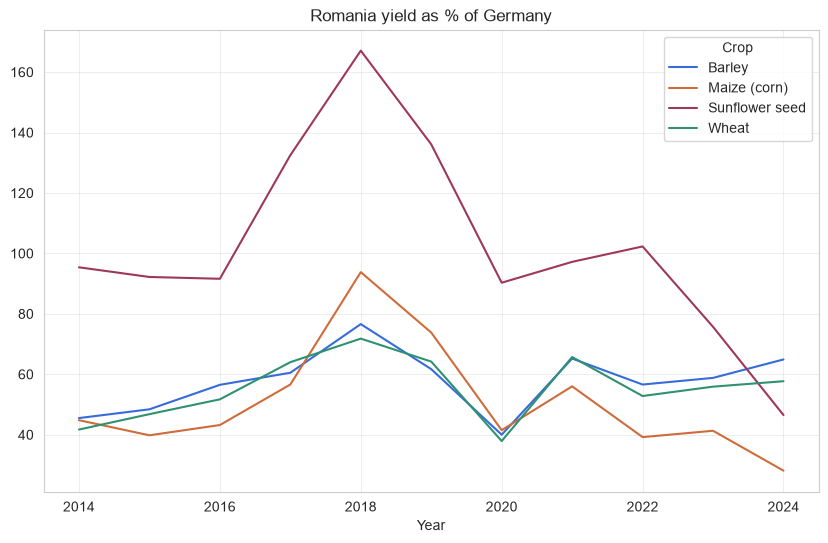

In [11]:
romania_pct_of_germany.T.plot(figsize=(10, 6))
plt.title('Romania yield as % of Germany')
plt.show()